### 1.Import Library

In [1]:
import warnings
from pathlib import Path
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")

### 2. Defined Pats

In [ ]:
PREPROCESS_PATH = Path(
    r"C:\Users\PC\Documents\CADT_Y4\Internship_II\Project\AI_Credit_Scoring_System\model_development\unsupervised_learning\preprocess"
)

MODEL_PATH = Path(
    r"C:\Users\PC\Documents\CADT_Y4\Internship_II\Project\AI_Credit_Scoring_System\model_development\unsupervised_learning\models"
)

RESULT_PATH = Path(
    r"C:\Users\PC\Documents\CADT_Y4\Internship_II\Project\AI_Credit_Scoring_System\model_development\unsupervised_learning\results\KMeans"
)

MODEL_PATH.mkdir(
    parents=True,
    exist_ok=True
)

RESULT_PATH.mkdir(
    parents=True,
    exist_ok=True
)

### 3. Load Preprocesed Data

In [3]:
X_new_train = pd.read_csv(
    PREPROCESS_PATH / "new_X_train.csv"
)

X_new_test = pd.read_csv(
    PREPROCESS_PATH / "new_X_test.csv"
)

X_old_train = pd.read_csv(
    PREPROCESS_PATH / "old_X_train.csv"
)

X_old_test = pd.read_csv(
    PREPROCESS_PATH / "old_X_test.csv"
)

print("NEW Train :", X_new_train.shape)
print("NEW Test  :", X_new_test.shape)

print("OLD Train :", X_old_train.shape)

NEW Train : (28000, 63)
NEW Test  : (7000, 63)
OLD Train : (28000, 67)


### 4. Elbow Method

In [4]:
def elbow_method(X, dataset_name):

    inertia = []

    for k in range(2, 11):

        model = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=10
        )

        model.fit(X)

        inertia.append(
            model.inertia_
        )

    plt.figure(figsize=(8,5))

    plt.plot(
        range(2,11),
        inertia,
        marker="o"
    )

    plt.xlabel("Number of Clusters")
    plt.ylabel("Inertia")
    plt.title(
        f"Elbow Method - {dataset_name}"
    )

    plt.grid(True)
    plt.show()

    return inertia

### 5. Evaluation Metrics

In [5]:
def evaluate_clusters(X):

    results = []

    for k in range(2,11):

        model = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=10
        )

        labels = model.fit_predict(X)

        results.append({
            "K": k,
            "Silhouette":
                silhouette_score(
                    X,
                    labels
                ),
            "Davies_Bouldin":
                davies_bouldin_score(
                    X,
                    labels
                ),
            "Calinski_Harabasz":
                calinski_harabasz_score(
                    X,
                    labels
                )
        })

    return pd.DataFrame(results)

- New Users Dataset

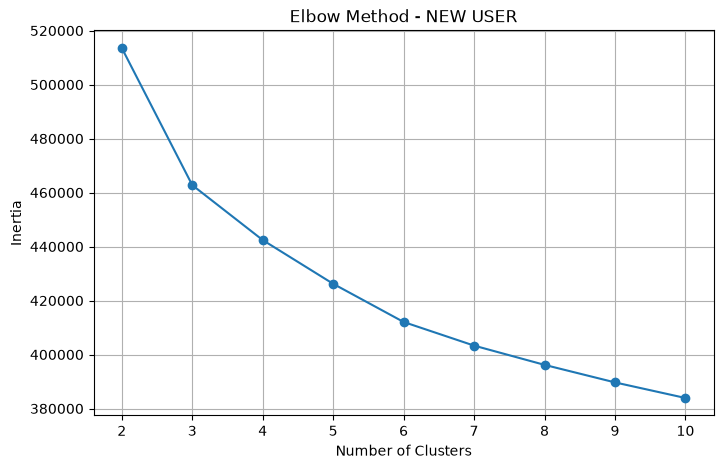

,K,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,2,0.141411,2.328334,3887.634016
1,3,0.111704,2.354701,3693.816686
2,4,0.096704,2.463847,3005.003353
3,5,0.083775,2.538125,2605.430127
4,6,0.081580,2.466887,2347.984028
5,7,0.073440,2.649276,2100.330998
6,8,0.065241,2.770686,1904.626624
7,9,0.066263,2.688917,1752.617531
8,10,0.056589,2.826461,1628.050611


In [6]:
elbow_method(
    X_new_train,
    "NEW USER"
)

new_scores = evaluate_clusters(
    X_new_train
)

display(new_scores)

- Old Users Dataset

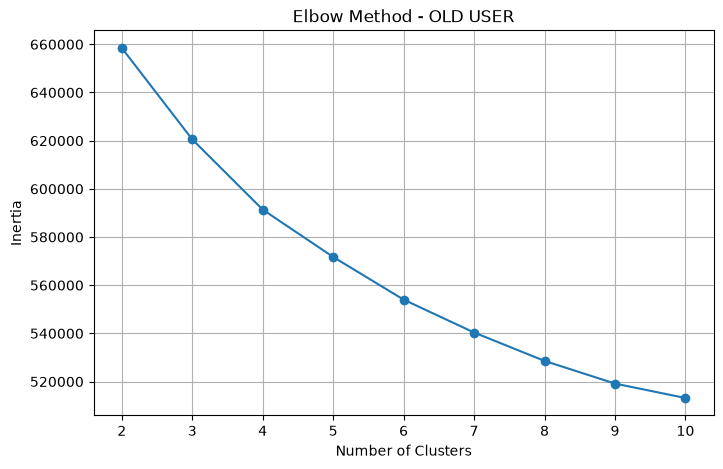

,K,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,2,0.123576,2.583991,3045.065075
1,3,0.077270,2.988142,2471.592631
2,4,0.071649,2.829138,2188.616967
3,5,0.070137,2.713786,1938.452427
4,6,0.069485,2.608732,1779.312777
5,7,0.067025,2.581641,1638.024703
6,8,0.058651,2.624883,1524.414024
7,9,0.055823,2.563569,1421.462345
8,10,0.050504,2.637551,1314.489802


In [7]:
elbow_method(
    X_old_train,
    "OLD USER"
)

old_scores = evaluate_clusters(
    X_old_train
)

display(old_scores)

### 6. Choose Best K

In [8]:
NEW_K = 3
OLD_K = 3

### 7. Train New Users Dataset

In [9]:
kmeans_new = KMeans(
    n_clusters=NEW_K,
    random_state=42,
    n_init=10
)

kmeans_new.fit(
    X_new_train
)

new_train_clusters = kmeans_new.predict(
    X_new_train
)

new_test_clusters = kmeans_new.predict(
    X_new_test
)

### 8. rain Old Users Dataset

In [10]:
kmeans_old = KMeans(
    n_clusters=OLD_K,
    random_state=42,
    n_init=10
)

kmeans_old.fit(
    X_old_train
)

old_train_clusters = kmeans_old.predict(
    X_old_train
)

old_test_clusters = kmeans_old.predict(
    X_old_test
)

### 9. Add Cluster Labels

In [11]:
X_new_cluster = X_new_train.copy()
X_new_cluster["cluster"] = new_train_clusters

X_old_cluster = X_old_train.copy()
X_old_cluster["cluster"] = old_train_clusters

### 10. Save Models

In [12]:
joblib.dump(
    kmeans_new,
    MODEL_PATH / "NEW_KMEANS.pkl"
)

joblib.dump(
    kmeans_old,
    MODEL_PATH / "OLD_KMEANS.pkl"
)

print("Models Saved.")

Models Saved.


### 11. Save Clustered Data

In [13]:
X_new_cluster.to_csv(
    RESULT_PATH / "new_cluster_result.csv",
    index=False
)

X_old_cluster.to_csv(
    RESULT_PATH / "old_cluster_result.csv",
    index=False
)

### 12. Save Evaluation Metrics

In [14]:
new_scores.to_csv(
    RESULT_PATH / "new_cluster_metrics.csv",
    index=False
)

old_scores.to_csv(
    RESULT_PATH / "old_cluster_metrics.csv",
    index=False
)

### 13. Save Cluster Centers

In [15]:
pd.DataFrame(
    kmeans_new.cluster_centers_,
    columns=X_new_train.columns
).to_csv(
    RESULT_PATH / "new_cluster_centers.csv",
    index=False
)

pd.DataFrame(
    kmeans_old.cluster_centers_,
    columns=X_old_train.columns
).to_csv(
    RESULT_PATH / "old_cluster_centers.csv",
    index=False
)

### 14. Cluster Distribution

In [16]:
print("NEW USER CLUSTER DISTRIBUTION")
print(
    X_new_cluster["cluster"]
    .value_counts()
    .sort_index()
)

print("\nOLD USER CLUSTER DISTRIBUTION")
print(
    X_old_cluster["cluster"]
    .value_counts()
    .sort_index()
)

NEW USER CLUSTER DISTRIBUTION
cluster
0    13503
1     5358
2     9139
Name: count, dtype: int64

OLD USER CLUSTER DISTRIBUTION
cluster
0    15525
1     5167
2     7308
Name: count, dtype: int64


### 15. Cluster Means

In [17]:
new_means = (
    X_new_cluster
    .groupby("cluster")
    .mean()
)

old_means = (
    X_old_cluster
    .groupby("cluster")
    .mean()
)

display(
    new_means.round(2)
)

display(
    old_means.round(2)
)

,num__age,num__dependents,num__monthly_income,num__income_source_diversity,num__expense_ratio,num__monthly_outflow,num__net_cash_flow,num__loan_amount,num__loan_tenure,num__existing_loan_count,...,nom__loan_purpose_Repair of the House,nom__loan_purpose_Shopping,nom__loan_purpose_Startup,nom__loan_purpose_Travel,nom__loan_purpose_Vehicles,nom__loan_purpose_Wedding/birth anniversary,nom__asset_ownership_Car,nom__asset_ownership_Computer,nom__asset_ownership_Motobike,nom__asset_ownership_Phone
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.34,0.62,-0.10,0.46,0.03,-0.06,-0.07,-0.05,0.05,0.01,...,0.1,0.10,0.1,0.1,0.1,0.10,0.25,0.25,0.25,0.25
1,0.11,0.56,1.64,0.45,-0.12,1.54,1.63,1.60,0.04,-0.01,...,0.1,0.10,0.1,0.1,0.1,0.09,0.24,0.26,0.26,0.24
2,-0.54,0.27,-0.12,0.45,0.02,-0.08,-0.08,-0.07,0.04,0.00,...,0.1,0.09,0.1,0.1,0.1,0.10,0.25,0.24,0.26,0.25


,num__age,num__dependents,num__monthly_income,num__income_source_diversity,num__expense_ratio,num__monthly_outflow,num__net_cash_flow,num__loan_amount,num__loan_tenure,num__existing_loan_count,...,nom__loan_purpose_Repair of the House,nom__loan_purpose_Shopping,nom__loan_purpose_Startup,nom__loan_purpose_Travel,nom__loan_purpose_Vehicles,nom__loan_purpose_Wedding/birth anniversary,nom__asset_ownership_Car,nom__asset_ownership_Computer,nom__asset_ownership_Motobike,nom__asset_ownership_Phone
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.03,0.56,-0.06,0.44,0.03,-0.02,-0.02,-0.02,0.13,-0.31,...,0.1,0.10,0.1,0.1,0.10,0.10,0.25,0.25,0.24,0.25
1,0.03,0.55,1.72,0.46,-0.12,1.61,1.69,1.62,0.10,-0.01,...,0.1,0.11,0.1,0.1,0.10,0.11,0.25,0.24,0.25,0.26
2,0.02,0.54,-0.22,0.44,0.03,-0.18,-0.16,-0.14,0.09,0.66,...,0.1,0.10,0.1,0.1,0.11,0.10,0.25,0.25,0.25,0.25


### 16. Save Cluster Means

In [18]:
new_means.to_csv(
    RESULT_PATH / "new_cluster_means.csv"
)

old_means.to_csv(
    RESULT_PATH / "old_cluster_means.csv"
)

### 17. PCA Visualization

- New Users

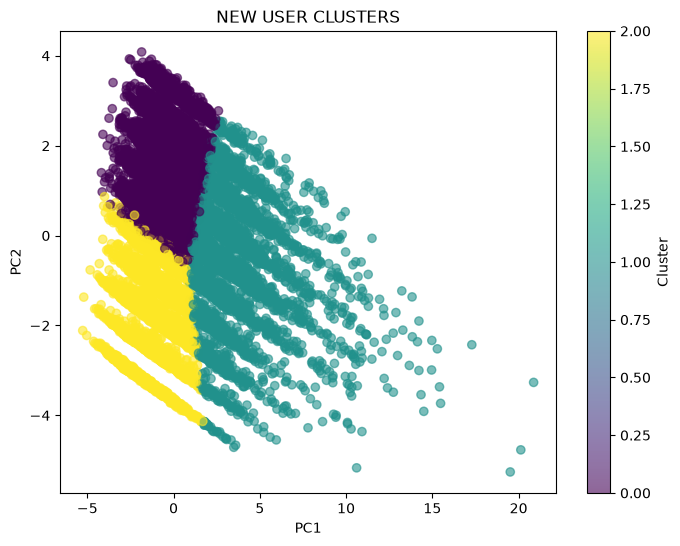

In [19]:
pca = PCA(
    n_components=2,
    random_state=42
)

X_new_pca = pca.fit_transform(
    X_new_train
)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_new_pca[:,0],
    X_new_pca[:,1],
    c=new_train_clusters,
    alpha=0.6
)

plt.colorbar(
    scatter,
    label="Cluster"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(
    "NEW USER CLUSTERS"
)

plt.show()

- Old Users

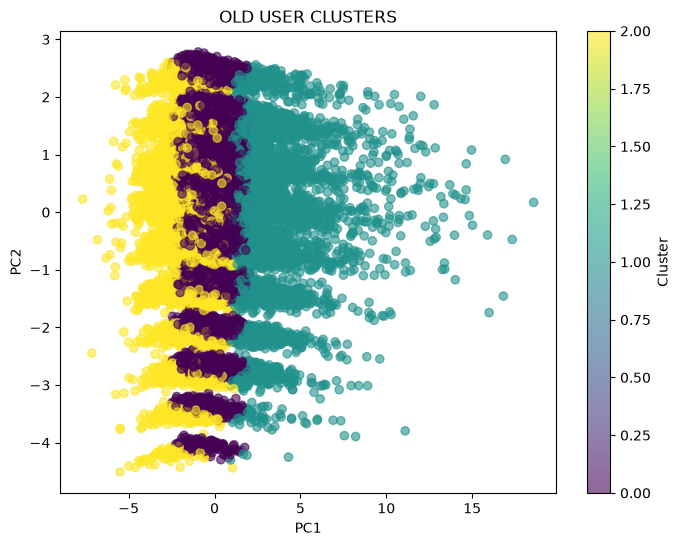

In [20]:
X_old_pca = pca.fit_transform(
    X_old_train
)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_old_pca[:,0],
    X_old_pca[:,1],
    c=old_train_clusters,
    alpha=0.6
)

plt.colorbar(
    scatter,
    label="Cluster"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(
    "OLD USER CLUSTERS"
)

plt.show()